In [1]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\stmos\AppData\Local\Programs\Python\Python311\python.exe
3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]


In [4]:
import tensorflow as tf
import cv2
import matplotlib
import sklearn
import seaborn as sns

print(tf.__version__)
print(cv2.__version__)
print(matplotlib.__version__)
print(sklearn.__version__)
print(sns.__version__)

2.20.0
4.13.0
3.10.7
1.7.2
0.13.2


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = r"C:\Users\stmos\Desktop\DR_images"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\stmos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      23,888,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,908,037 (91.20 MB)

 Trainable params: 23,908,037 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 780ms/step - accuracy: 0.6697 - loss: 1.0431 - val_accuracy: 0.7141 - val_loss: 0.7824
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 76s 827ms/step - accuracy: 0.7120 - loss: 0.7967 - val_accuracy: 0.7223 - val_loss: 0.7241
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 754ms/step - accuracy: 0.7195 - loss: 0.7678 - val_accuracy: 0.7291 - val_loss: 0.7300
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 67s 733ms/step - accuracy: 0.7195 - loss: 0.7809 - val_accuracy: 0.7209 - val_loss: 0.7645
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 738ms/step - accuracy: 0.7236 - loss: 0.7663 - val_accuracy: 0.7264 - val_loss: 0.7386
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 70s 765ms/step - accuracy: 0.7305 - loss: 0.7493 - val_accuracy: 0.7209 - val_loss: 0.7329
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 742ms/step - accuracy: 0.7349 - loss: 0.7226 - val_accuracy: 0.7360 - val_loss: 0.7570
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 738ms/step - accuracy: 0.7407 - loss: 0.7128 - val_accu

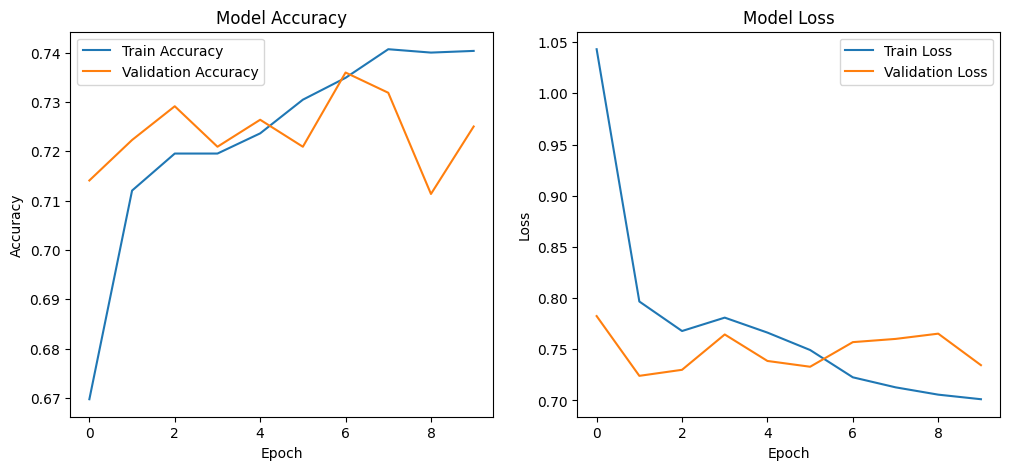

In [8]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [14]:
val_loss, val_acc = model.evaluate(val_data)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.7250 - loss: 0.7345
Validation Accuracy: 72.50%
Validation Loss: 0.7345


In [15]:
model.save("baseline_cnn_dr.keras")

In [16]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(5, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=output)
vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
vgg_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 17,926,725 (68.39 MB)

 Trainable params: 3,212,037 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [17]:
vgg_history = vgg_model.fit(train_data, validation_data=val_data, epochs=3)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 513s 6s/step - accuracy: 0.6186 - loss: 1.2550 - val_accuracy: 0.7127 - val_loss: 0.7908
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 526s 6s/step - accuracy: 0.6807 - loss: 0.9122 - val_accuracy: 0.7127 - val_loss: 0.7857
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 521s 6s/step - accuracy: 0.6919 - loss: 0.8777 - val_accuracy: 0.7209 - val_loss: 0.7516


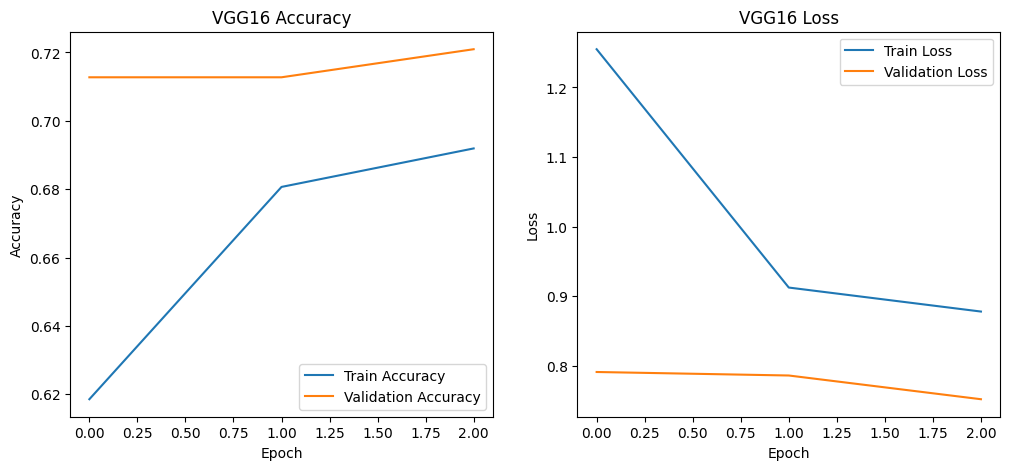

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(vgg_history.history['accuracy'], label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(vgg_history.history['loss'], label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [19]:
val_loss, val_acc = vgg_model.evaluate(val_data)
print(f"VGG16 Validation Accuracy: {val_acc*100:.2f}%")
print(f"VGG16 Validation Loss: {val_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.7209 - loss: 0.7516
VGG16 Validation Accuracy: 72.09%
VGG16 Validation Loss: 0.7516


In [20]:
vgg_model.save("vgg16_dr.keras")

In [21]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load ResNet50 without top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False # freeze pretrained layers

# Add your layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(5, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)
resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 85s 1us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 36,433,541 (138.98 MB)

 Trainable params: 12,845,829 (49.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [22]:
resnet_history = resnet_model.fit(train_data, validation_data=val_data, epochs=3)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.4374 - loss: 2.7123 - val_accuracy: 0.4938 - val_loss: 1.2615
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.4927 - loss: 1.3896 - val_accuracy: 0.4938 - val_loss: 1.2392
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.4927 - loss: 1.3167 - val_accuracy: 0.4938 - val_loss: 1.1909


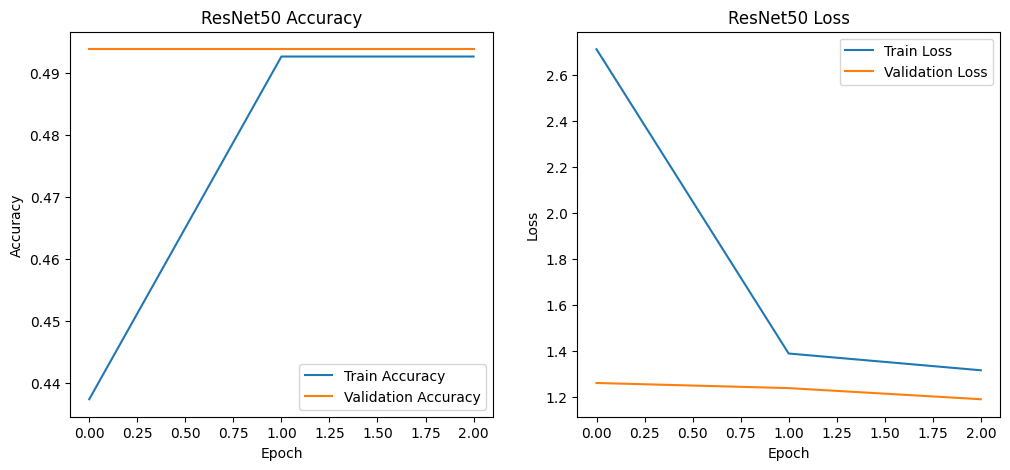

In [23]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(resnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(resnet_history.history['loss'], label='Train Loss')
plt.plot(resnet_history.history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [24]:
val_loss, val_acc = resnet_model.evaluate(val_data)
print(f"ResNet50 Validation Accuracy: {val_acc*100:.2f}%")
print(f"ResNet50 Validation Loss: {val_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.4938 - loss: 1.1909
ResNet50 Validation Accuracy: 49.38%
ResNet50 Validation Loss: 1.1909


In [25]:
resnet_model.save("resnet50_dr.keras")

In [26]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load MobileNet without top layer
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False # freeze pretrained layers

# Add custom layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(5, activation='softmax')(x) # 5 classes

mobilenet_model = Model(inputs=base_model.input, outputs=output)
mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

mobilenet_model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 112, 112, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)        │ (None, 112, 112, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_relu (ReLU)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1 (DepthwiseConv2D)          │ (None, 112, 112, 32)        │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_bn (BatchNormalization)    │ (None, 112, 112, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_relu (ReLU)                │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1 (Conv2D)                   │ (None, 112, 112, 64)        │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_bn (BatchNormalization)    │ (None, 112, 112, 64)        │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_relu (ReLU)                │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pad_2 (ZeroPadding2D)           │ (None, 113, 113, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2 (DepthwiseConv2D)          │ (None, 56, 56, 64)          │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_bn (BatchNormalization)    │ (None, 56, 56, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_relu (ReLU)                │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2 (Conv2D)                   │ (None, 56, 56, 128)         │           8,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_bn (BatchNormalization)    │ (None, 56, 56, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_relu (ReLU)                │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3 (DepthwiseConv2D)          │ (None, 56, 56, 128)         │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_bn (BatchNormalization)    │ (None, 56, 56, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_relu (ReLU)                │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_3 (Conv2D)                   │ (None, 56, 56, 128)         │          16,384 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 9,652,165 (36.82 MB)

 Trainable params: 6,423,301 (24.50 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [27]:
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=3)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 786ms/step - accuracy: 0.6165 - loss: 2.5983 - val_accuracy: 0.7401 - val_loss: 0.8811
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 722ms/step - accuracy: 0.6892 - loss: 0.9761 - val_accuracy: 0.7373 - val_loss: 0.7804
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 713ms/step - accuracy: 0.7079 - loss: 0.8725 - val_accuracy: 0.7373 - val_loss: 0.7393


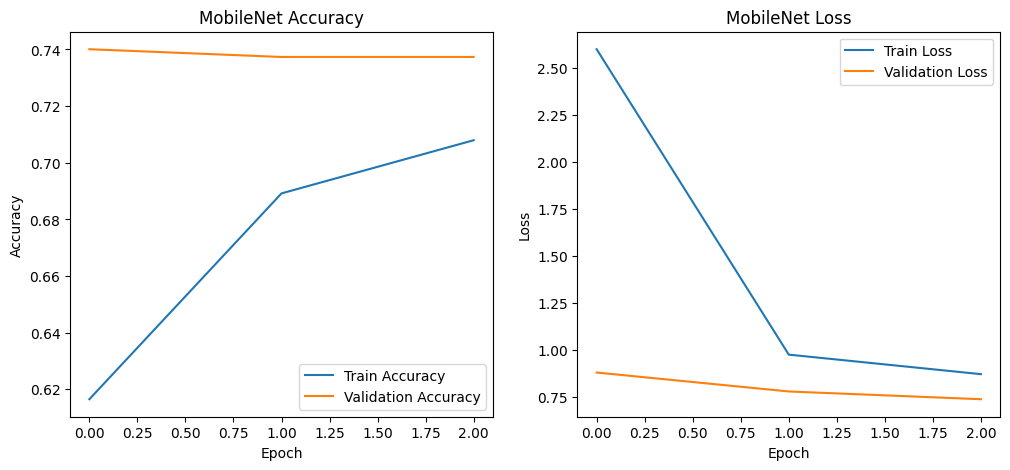

In [28]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(mobilenet_history.history['accuracy'], label='Train Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNet Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(mobilenet_history.history['loss'], label='Train Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')
plt.title('MobileNet Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [29]:
val_loss, val_acc = mobilenet_model.evaluate(val_data)
print(f"MobileNet Validation Accuracy: {val_acc*100:.2f}%")
print(f"MobileNet Validation Loss: {val_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 527ms/step - accuracy: 0.7373 - loss: 0.7393
MobileNet Validation Accuracy: 73.73%
MobileNet Validation Loss: 0.7393


In [30]:
mobilenet_model.save("mobilenet_dr.keras")

In [31]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load EfficientNetB0 without top layer
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False # freeze pretrained layers

# Add custom layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(5, activation='softmax')(x) # 5 classes

efficientnet_model = Model(inputs=base_model.input, outputs=output)
efficientnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 12,078,504 (46.08 MB)

 Trainable params: 8,028,933 (30.63 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [32]:
efficientnet_history = efficientnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=3)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.4678 - loss: 2.9004 - val_accuracy: 0.4938 - val_loss: 1.5631
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 90s 974ms/step - accuracy: 0.4903 - loss: 1.5438 - val_accuracy: 0.4938 - val_loss: 1.5125
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 90s 975ms/step - accuracy: 0.4927 - loss: 1.5021 - val_accuracy: 0.4938 - val_loss: 1.4699


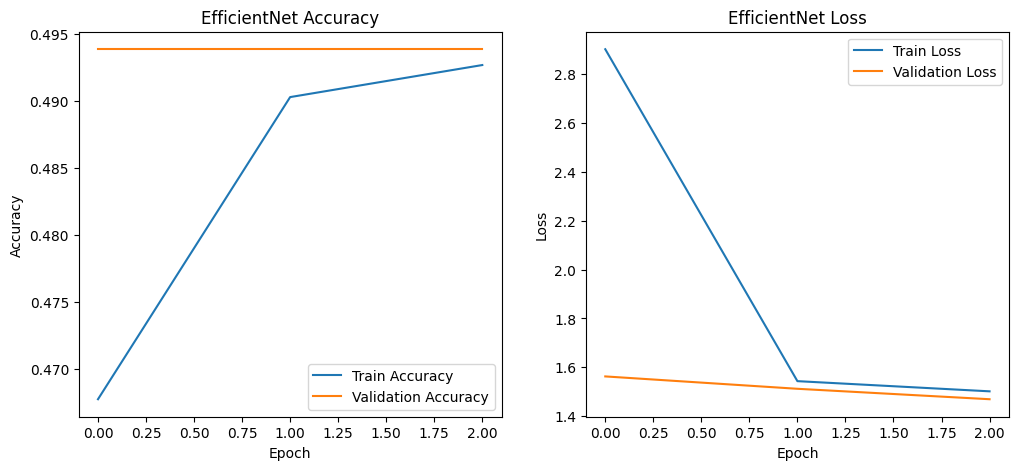

In [33]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(efficientnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(efficientnet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('EfficientNet Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(efficientnet_history.history['loss'], label='Train Loss')
plt.plot(efficientnet_history.history['val_loss'], label='Validation Loss')
plt.title('EfficientNet Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [34]:
val_loss, val_acc = efficientnet_model.evaluate(val_data)
print(f"EfficientNetB0 Validation Accuracy: {val_acc*100:.2f}%")
print(f"EfficientNetB0 Validation Loss: {val_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 725ms/step - accuracy: 0.4938 - loss: 1.4699
EfficientNetB0 Validation Accuracy: 49.38%
EfficientNetB0 Validation Loss: 1.4699


In [35]:
efficientnet_model.save("efficientnetb0_dr.keras")

In [37]:
# CNN
cnn_val_loss, cnn_val_acc = model.evaluate(val_data)

# VGG16
vgg_val_loss, vgg_val_acc = vgg_model.evaluate(val_data)

# ResNet50
resnet_val_loss, resnet_val_acc = resnet_model.evaluate(val_data)

# MobileNet
mobilenet_val_loss, mobilenet_val_acc = mobilenet_model.evaluate(val_data)

# EfficientNetB0
efficientnet_val_loss, efficientnet_val_acc = efficientnet_model.evaluate(val_data)

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.7250 - loss: 0.7345
23/23 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.7209 - loss: 0.7516
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.4938 - loss: 1.1909
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 529ms/step - accuracy: 0.7373 - loss: 0.7393
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 721ms/step - accuracy: 0.4938 - loss: 1.4699


In [38]:
import pandas as pd

comparison_data = {
    "Model": ["CNN", "VGG16", "ResNet50", "MobileNet", "EfficientNetB0"],
    "Validation Accuracy (%)": [
        cnn_val_acc*100,
        vgg_val_acc*100,
        resnet_val_acc*100,
        mobilenet_val_acc*100,
        efficientnet_val_acc*100
    ],
    "Validation Loss": [
        cnn_val_loss,
        vgg_val_loss,
        resnet_val_loss,
        mobilenet_val_loss,
        efficientnet_val_loss
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison

,Model,Validation Accuracy (%),Validation Loss
0,CNN,72.503418,0.734495
1,VGG16,72.093022,0.751609
2,ResNet50,49.384406,1.190859
3,MobileNet,73.734611,0.739301
4,EfficientNetB0,49.384406,1.469891


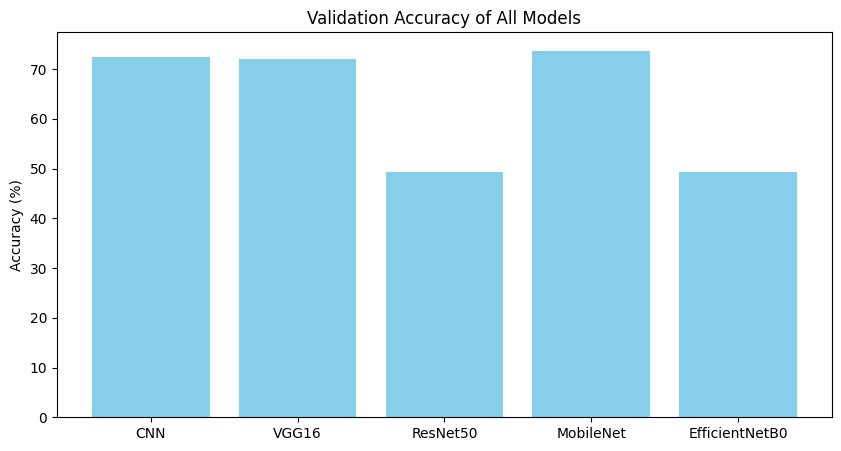

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df_comparison["Model"], df_comparison["Validation Accuracy (%)"], color='skyblue')
plt.title("Validation Accuracy of All Models")
plt.ylabel("Accuracy (%)")
plt.show()